# Práctica 7 — Codificación, transformación y escalamiento

**FP13 · Inteligencia Artificial · UAG**
Sesión 7 — Unidad 4, subtemas 4.4, 4.5 y 4.6

---

Trabajamos con el **Heart Failure Prediction Dataset**: 918 pacientes y 11 predictores clínicos,
provenientes de cinco estudios de cardiopatía isquémica. El desenlace `HeartDisease` indica
enfermedad coronaria confirmada por angiografía.

El objetivo es construir una matriz que un estimador de scikit-learn pueda consumir, tomando y
**justificando** tres decisiones por cada columna:

| Decisión | Subtema | Pregunta que responde |
|---|---|---|
| Codificar | 4.4 | ¿Cómo convierto texto en número sin inventar un orden? |
| Transformar | 4.5 | ¿Debo cambiar la **forma** de la distribución? |
| Escalar | 4.6 | ¿Debo cambiar la **magnitud** para que compita en igualdad? |

> **Aviso.** Este conjunto tiene defectos reales de captura. No los vamos a ocultar: son el mejor
> material didáctico de la práctica. Quien aplique transformaciones sin diagnosticar primero
> obtendrá resultados **peores** que si no hubiera hecho nada, y lo va a comprobar con números.

---
## Parte 0 · Preparación

Fijamos la semilla al inicio y no la volvemos a tocar: todo resultado de este cuaderno debe ser
reproducible por cualquier compañero que ejecute las celdas en orden.

In [3]:
# [1] Entorno y semilla
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.color": "#DCE1EA", "axes.axisbelow": True})

In [4]:
# [2] Carga del conjunto de datos
def cargar_datos():
    # Intenta Kaggle; si no hay red, usa la copia local heart.csv
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        return kagglehub.dataset_load(
            KaggleDatasetAdapter.PANDAS,
            "fedesoriano/heart-failure-prediction",
            "heart.csv")
    except Exception as e:
        print("Kaggle no disponible (", type(e).__name__, ") -> copia local")
        return pd.read_csv("heart.csv")

df = cargar_datos()
print("Forma:", df.shape)
df.head()

100%|██████████| 35.1k/35.1k [00:00<00:00, 8.11MB/s]

Forma: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


---
## Parte 1 · Reconocimiento

Antes de tocar nada: qué tipo de dato es cada columna, cuántos valores distintos toma y cuántos
faltan. La clasificación en nominal / ordinal / numérica es una decisión **clínica**, no estadística.

In [5]:
# [3] Inventario y clasificación de las columnas
resumen = pd.DataFrame({
    "tipo":     df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "nulos":    df.isna().sum(),
})
print(resumen.to_string())

NOMINALES = ["ChestPainType", "RestingECG"]     # sin orden intrinseco
BINARIAS  = ["Sex", "ExerciseAngina"]           # dos categorias
ORDINAL   = ["ST_Slope"]                        # orden pronostico discutible
NUMERICAS = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
OBJETIVO  = "HeartDisease"

print("\nCategorias de cada variable de texto:")
for c in NOMINALES + BINARIAS + ORDINAL:
    conteo = {k: int(v) for k, v in df[c].value_counts().items()}
    print(f"  {c:<16} {conteo}")

print("\nBalance del objetivo:", round(df[OBJETIVO].mean(), 3))

                   tipo  n_unicos  nulos
Age               int64        50      0
Sex              object         2      0
ChestPainType    object         4      0
RestingBP         int64        67      0
Cholesterol       int64       222      0
FastingBS         int64         2      0
RestingECG       object         3      0
MaxHR             int64       119      0
ExerciseAngina   object         2      0
Oldpeak         float64        53      0
ST_Slope         object         3      0
HeartDisease      int64         2      0

Categorias de cada variable de texto:
  ChestPainType    {'ASY': 496, 'NAP': 203, 'ATA': 173, 'TA': 46}
  RestingECG       {'Normal': 552, 'LVH': 188, 'ST': 178}
  Sex              {'M': 725, 'F': 193}
  ExerciseAngina   {'N': 547, 'Y': 371}
  ST_Slope         {'Flat': 460, 'Up': 395, 'Down': 63}

Balance del objetivo: 0.553


Observe que **`nulos` vale 0 en todas las columnas**: no hay un solo `NaN` declarado.
Guarde esa observación, porque en la Parte 2 la vamos a desmentir.

La siguiente función acompaña toda la práctica. El **coeficiente de asimetría** es el tercer momento
estandarizado: positivo significa cola a la derecha, negativo cola a la izquierda.

In [6]:
# [4] Función de diagnóstico y primer barrido
def diagnostico(x, nombre=""):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    return {
        "variable": nombre,
        "min": x.min(), "max": x.max(),
        "media": x.mean(), "mediana": np.median(x),
        "asimetria": stats.skew(x),
        "ceros": int((x == 0).sum()),
        "negativos": int((x < 0).sum()),
    }

pd.DataFrame([diagnostico(df[c], c) for c in NUMERICAS]).round(3)

,variable,min,max,media,mediana,asimetria,ceros,negativos
0,Age,28.0,77.0,53.511,54.0,-0.196,0,0
1,RestingBP,0.0,200.0,132.397,130.0,0.180,1,0
2,Cholesterol,0.0,603.0,198.800,223.0,-0.609,172,0
3,MaxHR,60.0,202.0,136.809,138.0,-0.144,0,0
4,Oldpeak,-2.6,6.2,0.887,0.6,1.021,368,13


---
## Parte 2 · Los ceros imposibles

La tabla anterior contiene una anomalía grave. Búsquela antes de ejecutar la siguiente celda:
hay dos columnas con ceros que son **fisiológicamente imposibles**.

RestingBP    ceros =    1   (  0.1 %)
Cholesterol  ceros =  172   ( 18.7 %)

Un colesterol de 0 mg/dL o una presion de 0 mmHg son imposibles:
son datos FALTANTES codificados como 0 en la base original.



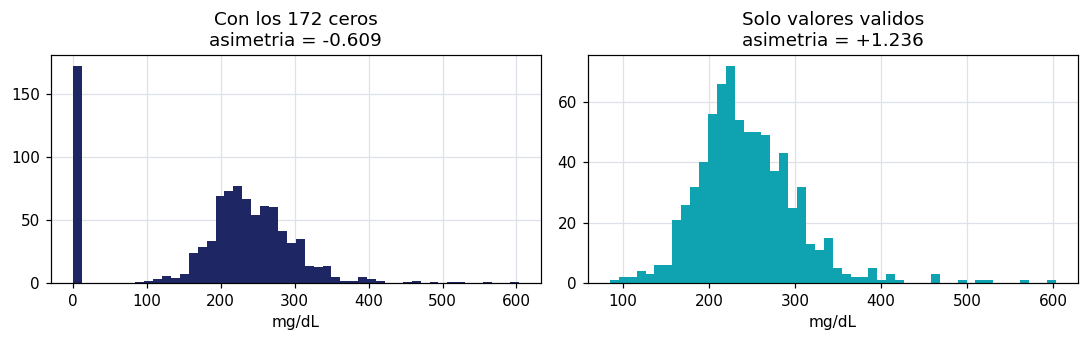

In [7]:
# [5] Detección de los ceros y el histograma que lo revela
for c in ["RestingBP", "Cholesterol"]:
    n0 = int((df[c] == 0).sum())
    print(f"{c:<12} ceros = {n0:>4}   ({n0 / len(df) * 100:5.1f} %)")

print("\nUn colesterol de 0 mg/dL o una presion de 0 mmHg son imposibles:")
print("son datos FALTANTES codificados como 0 en la base original.\n")

chol_crudo = df["Cholesterol"].values.astype(float)
chol_valid = chol_crudo[chol_crudo > 0]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(chol_crudo, bins=50, color="#1E2664")
ax[0].set_title(f"Con los 172 ceros\nasimetria = {stats.skew(chol_crudo):+.3f}")
ax[1].hist(chol_valid, bins=50, color="#0FA3B1")
ax[1].set_title(f"Solo valores validos\nasimetria = {stats.skew(chol_valid):+.3f}")
for a in ax:
    a.set_xlabel("mg/dL")
plt.tight_layout()
plt.show()

**Lea los dos coeficientes con cuidado.** Con los ceros dentro la asimetría es **negativa**: un
diagnóstico automático diría «cola izquierda». Sin ellos es **positiva** y de magnitud moderada-alta.

El signo se invirtió por un artefacto de captura. Ocurre porque el coeficiente eleva las
desviaciones al cubo, y 172 registros clavados muy a la izquierda de la media dominan la suma.
Cualquier decisión tomada sobre la primera cifra habría sido la contraria de la correcta.

In [8]:
# [6] Marcar los ceros como faltantes
df_lim = df.copy()
df_lim.loc[df_lim["Cholesterol"] == 0, "Cholesterol"] = np.nan
df_lim.loc[df_lim["RestingBP"] == 0, "RestingBP"] = np.nan

print("Faltantes tras el marcado explicito:")
print(df_lim[NUMERICAS].isna().sum())

Faltantes tras el marcado explicito:
Age              0
RestingBP        1
Cholesterol    172
MaxHR            0
Oldpeak          0
dtype: int64


---
## Parte 3 · Subtema 4.4 — Codificación

### 3.1 La variable ordinal discutible

`ST_Slope` describe la pendiente del segmento ST durante el esfuerzo. Hay un argumento fisiológico
para ordenarla —ascendente es lo normal, plana es sospechosa, descendente es isquémica— pero ese
orden hay que **verificarlo contra los datos**, no darlo por bueno.

In [9]:
# [7] Codificación ordinal y verificación del orden
from sklearn.preprocessing import OrdinalEncoder

orden_st = [["Down", "Flat", "Up"]]      # hipotesis: de peor a mejor pronostico
enc_ord = OrdinalEncoder(categories=orden_st)
st_cod = enc_ord.fit_transform(df_lim[["ST_Slope"]])

mapa = pd.DataFrame({"ST_Slope": df_lim["ST_Slope"], "codigo": st_cod.ravel()})
print("Mapeo aplicado:")
print(mapa.drop_duplicates().sort_values("codigo").to_string(index=False))

print("\nTasa observada de cardiopatia por categoria:")
print(df_lim.groupby("ST_Slope")[OBJETIVO].agg(["count", "mean"]).round(3))

Mapeo aplicado:
ST_Slope  codigo
    Down     0.0
    Flat     1.0
      Up     2.0

Tasa observada de cardiopatia por categoria:
          count   mean
ST_Slope              
Down         63  0.778
Flat        460  0.828
Up          395  0.197


**La hipótesis no se sostiene.** La tasa es 0.778 para `Down`, **sube** a 0.828 para `Flat` y sólo
entonces cae a 0.197 para `Up`. No es monótona respecto del orden que declaramos: `Flat` resulta ser
la categoría de mayor riesgo.

Una regresión logística que reciba 0, 1, 2 asumirá un efecto lineal que los datos contradicen en el
primer tramo. La decisión defendible aquí es **tratar `ST_Slope` como nominal**.

Ésa es la lección: la codificación ordinal no se justifica con intuición fisiológica, se justifica
verificándola.

### 3.2 One-hot y la trampa de la variable ficticia

In [10]:
# [8] One-hot, el efecto de drop y la colinealidad perfecta
from sklearn.preprocessing import OneHotEncoder

CATS = NOMINALES + BINARIAS + ORDINAL

for d in [None, "first", "if_binary"]:
    ohe = OneHotEncoder(drop=d, sparse_output=False).fit(df_lim[CATS])
    print(f"drop={str(d):<10} -> {ohe.transform(df_lim[CATS]).shape[1]:>2} columnas")

ohe = OneHotEncoder(sparse_output=False).fit(df_lim[CATS])
M = pd.DataFrame(ohe.transform(df_lim[CATS]), columns=ohe.get_feature_names_out())

grupo = [c for c in M.columns if c.startswith("RestingECG")]
print("\nColumnas de RestingECG:", grupo)
print("Suma por fila -> valores unicos:", M[grupo].sum(axis=1).unique())
print("\nSiempre vale 1. Esa columna de unos ES el intercepto del modelo:")
print("hay una combinacion lineal exacta -> colinealidad perfecta.")
print("Se resuelve eliminando una columna de referencia por variable (drop='first').")

drop=None       -> 14 columnas
drop=first      ->  9 columnas
drop=if_binary  -> 12 columnas

Columnas de RestingECG: ['RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST']
Suma por fila -> valores unicos: [1.]

Siempre vale 1. Esa columna de unos ES el intercepto del modelo:
hay una combinacion lineal exacta -> colinealidad perfecta.
Se resuelve eliminando una columna de referencia por variable (drop='first').


In [11]:
# [9] Qué pasa con una categoría nunca vista
ohe_cp = OneHotEncoder(handle_unknown="ignore",
                       sparse_output=False).fit(df_lim[["ChestPainType"]])

nuevos = pd.DataFrame({"ChestPainType": ["ASY", "NAP", "CATEGORIA_NUEVA"]})
print("Columnas aprendidas:", ohe_cp.get_feature_names_out())
print("\nCodificacion de los tres pacientes:")
print(ohe_cp.transform(nuevos))
print("\nLa categoria desconocida da una fila de ceros: el modelo no falla,")
print("pero tampoco recibe informacion. Con handle_unknown='error' habria excepcion.")

Columnas aprendidas: ['ChestPainType_ASY' 'ChestPainType_ATA' 'ChestPainType_NAP'
 'ChestPainType_TA']

Codificacion de los tres pacientes:
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]]

La categoria desconocida da una fila de ceros: el modelo no falla,
pero tampoco recibe informacion. Con handle_unknown='error' habria excepcion.


---
## Parte 4 · Subtema 4.5 — Transformación de la distribución

### 4.1 Transformar sin diagnosticar empeora los datos

Apliquemos `log1p` a la columna cruda, como haría un flujo automático, y después recorramos la
**escalera de potencias** sobre la variable ya saneada.

asimetria cruda (con los 172 ceros) = -0.609
asimetria con log1p sobre TODO      = -1.566   <-- EMPEORA

x  (original)    asimetria = +1.236
sqrt(x)          asimetria = +0.542
log(x)           asimetria = -0.095
-1/x             asimetria = -1.516


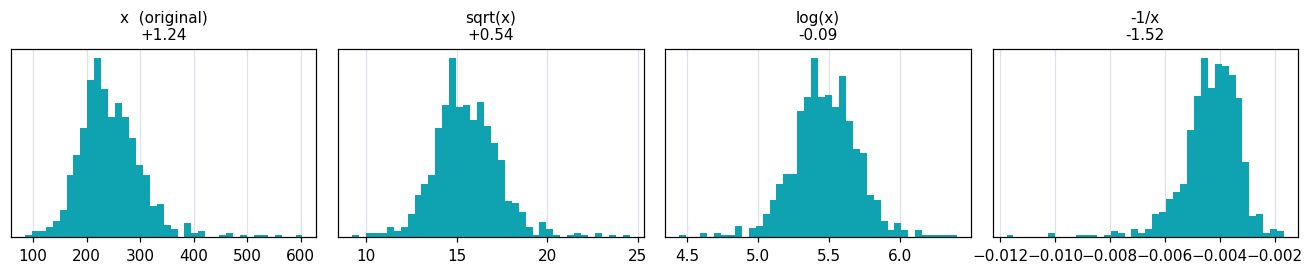

In [12]:
# [10] La transformación ciega y la escalera de potencias
print(f"asimetria cruda (con los 172 ceros) = {stats.skew(chol_crudo):+.3f}")
print(f"asimetria con log1p sobre TODO      = {stats.skew(np.log1p(chol_crudo)):+.3f}   <-- EMPEORA")
print()

escalera = {
    "x  (original)": chol_valid,
    "sqrt(x)":       np.sqrt(chol_valid),
    "log(x)":        np.log(chol_valid),
    "-1/x":          -1 / chol_valid,
}
for k, v in escalera.items():
    print(f"{k:<16} asimetria = {stats.skew(v):+.3f}")

fig, ax = plt.subplots(1, 4, figsize=(12, 2.6))
for a, (t, v) in zip(ax, escalera.items()):
    a.hist(v, bins=40, color="#0FA3B1")
    a.set_title(f"{t}\n{stats.skew(v):+.2f}", fontsize=10)
    a.set_yticks([])
plt.tight_layout()
plt.show()

La escalera baja de +1.24 a +0.54 con la raíz, llega a **−0.10 con el logaritmo** —el punto óptimo—
y **sobrecorrige** hasta −1.52 con la recíproca. Más transformación no es mejor transformación.

### 4.2 Box-Cox contra Yeo-Johnson

`Oldpeak` es la depresión del segmento ST inducida por ejercicio. Tiene ceros legítimos y **valores
negativos** (elevación del ST). Esa combinación decide cuál de las dos es aplicable.

In [13]:
# [11] Box-Cox falla, Yeo-Johnson resuelve
from sklearn.preprocessing import PowerTransformer

old = df_lim[["Oldpeak"]]
v = old.values.ravel()
print(f"Oldpeak:  min = {v.min():.2f}   ceros = {int((v == 0).sum())}"
      f"   negativos = {int((v < 0).sum())}")

try:
    PowerTransformer(method="box-cox").fit(old)
except ValueError as e:
    print("\nBox-Cox ->", type(e).__name__, ":", e)

yj = PowerTransformer(method="yeo-johnson").fit(old)
old_yj = yj.transform(old).ravel()
print(f"\nYeo-Johnson   lambda = {yj.lambdas_[0]:+.3f}"
      f"   asimetria {stats.skew(v):+.3f} -> {stats.skew(old_yj):+.3f}")

Oldpeak:  min = -2.60   ceros = 368   negativos = 13

Box-Cox -> ValueError : The Box-Cox transformation can only be applied to strictly positive data

Yeo-Johnson   lambda = +0.320   asimetria +1.021 -> -0.301


**Sobre lambda.** Es el exponente de la transformación, estimado por máxima verosimilitud. Funciona
como una escalera continua: λ = 1 es no transformar, λ = 0.5 es la raíz, λ = 0 es el logaritmo.
**λ menor que 1 corrige cola derecha; λ mayor que 1 corrige cola izquierda.**

### 4.3 Cola izquierda: el caso `MaxHR`

La frecuencia cardiaca máxima tiene un techo fisiológico aproximado de 220 menos la edad. Como todo
lo acotado por arriba, su cola se estira hacia la **izquierda**.

In [14]:
# [12] Asimetría negativa y lambda mayor que 1
mh = df_lim["MaxHR"].values.astype(float)
yj2 = PowerTransformer(method="yeo-johnson").fit(mh.reshape(-1, 1))

print(f"MaxHR original       asimetria = {stats.skew(mh):+.3f}   (cola IZQUIERDA)")
print(f"MaxHR al cuadrado    asimetria = {stats.skew(mh ** 2):+.3f}   (sobrecorrige)")
print(f"MaxHR Yeo-Johnson    asimetria = "
      f"{stats.skew(yj2.transform(mh.reshape(-1, 1)).ravel()):+.3f}"
      f"   lambda = {yj2.lambdas_[0]:+.3f}")
print("\nEl algoritmo estima lambda > 1, justo lo que corresponde a sesgo negativo.")
print("Pero atencion: la asimetria original ya era -0.144, dentro de la banda")
print("de 'no transformar'. Que exista un lambda optimo no significa que haga falta.")

MaxHR original       asimetria = -0.144   (cola IZQUIERDA)
MaxHR al cuadrado    asimetria = +0.268   (sobrecorrige)
MaxHR Yeo-Johnson    asimetria = -0.041   lambda = +1.234

El algoritmo estima lambda > 1, justo lo que corresponde a sesgo negativo.
Pero atencion: la asimetria original ya era -0.144, dentro de la banda
de 'no transformar'. Que exista un lambda optimo no significa que haga falta.


### 4.4 Evidencia gráfica: el gráfico Q-Q

El coeficiente resume la desviación en un número; el gráfico Q-Q muestra **dónde** está.

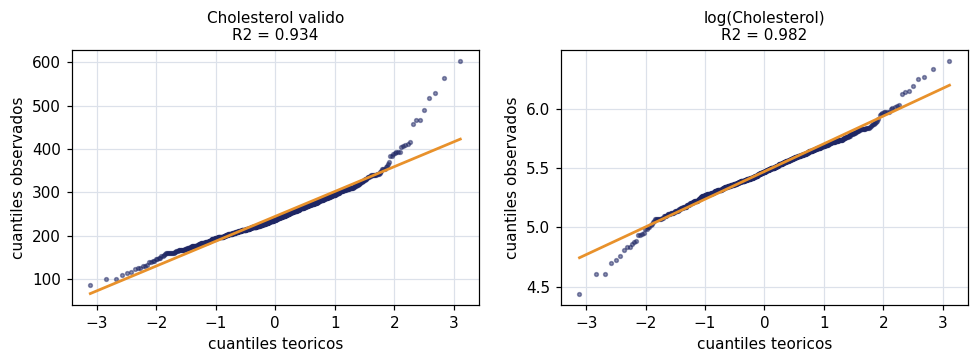

In [15]:
# [13] Gráfico Q-Q antes y después
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for a, d, t in zip(ax, [chol_valid, np.log(chol_valid)],
                   ["Cholesterol valido", "log(Cholesterol)"]):
    (osm, osr), (sl, ic, r) = stats.probplot(d, dist="norm")
    a.scatter(osm, osr, s=6, alpha=0.5, color="#1E2664")
    a.plot(osm, sl * osm + ic, color="#E8912B", lw=1.8)
    a.set_title(f"{t}\nR2 = {r ** 2:.3f}", fontsize=10)
    a.set_xlabel("cuantiles teoricos")
    a.set_ylabel("cuantiles observados")
plt.tight_layout()
plt.show()

---
## Parte 5 · Subtema 4.6 — Escalamiento

Comparamos los cuatro escaladores en dos escenarios: los datos tal cual, y los mismos datos con
cinco errores de captura (un dígito de más al teclear). Fíjese en la última columna.

In [16]:
# [14] Los cuatro escaladores, con y sin valores extremos
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   MaxAbsScaler, RobustScaler)

X1 = df_lim[["Cholesterol"]].fillna(df_lim["Cholesterol"].median()).values

X2 = X1.copy()                                   # cinco errores de captura
idx = rng.choice(len(X2), 5, replace=False)
X2[idx] = X2[idx] * 10

def comparar(X, etiqueta):
    out = []
    for nombre, sc in [("Standard", StandardScaler()), ("MinMax", MinMaxScaler()),
                       ("MaxAbs", MaxAbsScaler()), ("Robust", RobustScaler())]:
        Z = sc.fit_transform(X).ravel()
        p5, p95 = np.percentile(Z, [5, 95])
        out.append({"escenario": etiqueta, "escalador": nombre,
                    "max": Z.max(), "amplitud_90pct": p95 - p5,
                    "asimetria": stats.skew(Z)})
    return out

pd.DataFrame(comparar(X1, "sin errores") + comparar(X2, "con 5 errores")).round(3)

,escenario,escalador,max,amplitud_90pct,asimetria
0,sin errores,Standard,6.741,3.060,1.445
1,sin errores,MinMax,1.000,0.315,1.445
2,sin errores,MaxAbs,1.000,0.271,1.445
3,sin errores,Robust,6.906,3.081,1.445
4,con 5 errores,Standard,13.546,1.078,11.318
5,con 5 errores,MinMax,1.000,0.074,11.318
6,con 5 errores,MaxAbs,1.000,0.071,11.318
7,con 5 errores,Robust,39.870,3.147,11.318


**Dos lecturas.** La columna `asimetria` es idéntica dentro de cada escenario: las cuatro son
transformaciones afines y ninguna puede cambiar la forma, sólo el tramo del eje.

Y sin errores de captura, `Standard` y `Robust` dan casi lo mismo: **la ventaja de `RobustScaler` no
es universal**, aparece sólo cuando existe la cola. Bastan cinco errores para que `MinMax` y
`MaxAbs` compriman a casi todos los pacientes contra el extremo del eje.

In [17]:
# [15] ¿A qué algoritmos les importa el escalamiento?
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

Xtr, Xte, ytr, yte = train_test_split(
    df_lim[NUMERICAS], df_lim[OBJETIVO], test_size=0.30,
    random_state=SEED, stratify=df_lim[OBJETIVO])

for nombre, modelo in [("KNN (k=15)", KNeighborsClassifier(15)),
                       ("Random Forest", RandomForestClassifier(300, random_state=SEED))]:
    # clone() es indispensable: sin el, ambos Pipeline compartirian la MISMA
    # instancia del estimador y el segundo fit sobrescribiria al primero.
    sin = Pipeline([("imp", SimpleImputer(strategy="median")),
                    ("clf", clone(modelo))]).fit(Xtr, ytr)
    con = Pipeline([("imp", SimpleImputer(strategy="median")),
                    ("esc", StandardScaler()),
                    ("clf", clone(modelo))]).fit(Xtr, ytr)
    a1 = roc_auc_score(yte, sin.predict_proba(Xte)[:, 1])
    a2 = roc_auc_score(yte, con.predict_proba(Xte)[:, 1])
    print(f"{nombre:<15} sin escalar = {a1:.3f}   escalado = {a2:.3f}   delta = {a2 - a1:+.3f}")

KNN (k=15)      sin escalar = 0.762   escalado = 0.844   delta = +0.082
Random Forest   sin escalar = 0.837   escalado = 0.837   delta = -0.000


KNN gana ocho centésimas de AUC; el bosque aleatorio no se mueve **ni una milésima**, porque sólo
compara cada valor contra un umbral y el escalamiento no altera el orden.

---
## Parte 6 · Integración

Comparamos dos formas de preparar exactamente los mismos datos:

- **Ruta A** — sin diagnóstico previo: los ceros imposibles se tratan como mediciones reales,
  `MinMaxScaler` y one-hot de todo.
- **Ruta B** — con lo aprendido hoy: ceros marcados como faltantes, `Yeo-Johnson`, `RobustScaler`,
  ordinal declarado y `drop='if_binary'`.

Todo dentro de un `Pipeline`, de modo que cada pliegue de la validación cruzada ajuste sus propios
transformadores. Ésa es la garantía contra la fuga de información.

In [18]:
# [16] Las dos rutas y su comparación por validación cruzada
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

CAT = NOMINALES + BINARIAS
ORD = ["ST_Slope"]

ruta_A = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("esc", MinMaxScaler())]), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT + ORD),
])

ruta_B = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("pot", PowerTransformer(method="yeo-johnson")),
                      ("esc", RobustScaler())]), NUMERICAS),
    ("ord", OrdinalEncoder(categories=[["Down", "Flat", "Up"]]), ORD),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), CAT),
])

X = df.drop(columns=[OBJETIVO]).copy()
X.loc[X["Cholesterol"] == 0, "Cholesterol"] = np.nan     # el saneamiento de la Parte 2
X.loc[X["RestingBP"] == 0, "RestingBP"] = np.nan
y = df[OBJETIVO]

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
for nombre, pre in [("Ruta A - sin diagnostico", ruta_A),
                    ("Ruta B - con 4.3 a 4.6 ", ruta_B)]:
    for clf_nom, clf in [("LogReg", LogisticRegression(max_iter=2000)),
                         ("KNN   ", KNeighborsClassifier(15))]:
        s = cross_val_score(Pipeline([("pre", pre), ("clf", clf)]),
                            X, y, cv=cv, scoring="roc_auc")
        print(f"{nombre}   {clf_nom}   AUC = {s.mean():.3f} +/- {s.std():.3f}")

Ruta A - sin diagnostico   LogReg   AUC = 0.915 +/- 0.023
Ruta A - sin diagnostico   KNN      AUC = 0.905 +/- 0.029
Ruta B - con 4.3 a 4.6    LogReg   AUC = 0.906 +/- 0.016
Ruta B - con 4.3 a 4.6    KNN      AUC = 0.905 +/- 0.013
